In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [62]:
df = pd.read_csv('height-weight.csv')

In [63]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


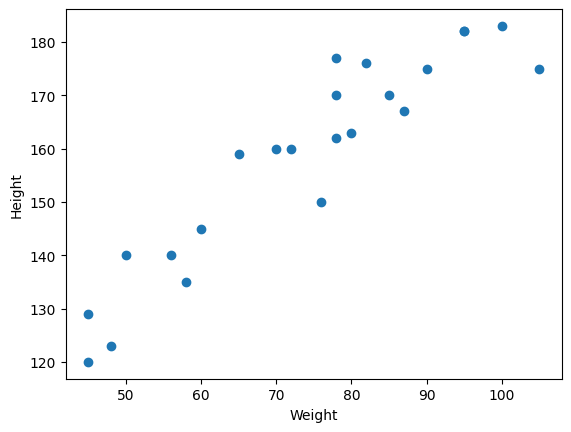

In [64]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [65]:
## dividing our dataset into dependent and independent features

X = df[['Weight']]  # Independent feature
y = df[['Height']]  # Dependent feature

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [68]:
X.shape

(23, 1)

In [69]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18, 1), (5, 1))

In [70]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

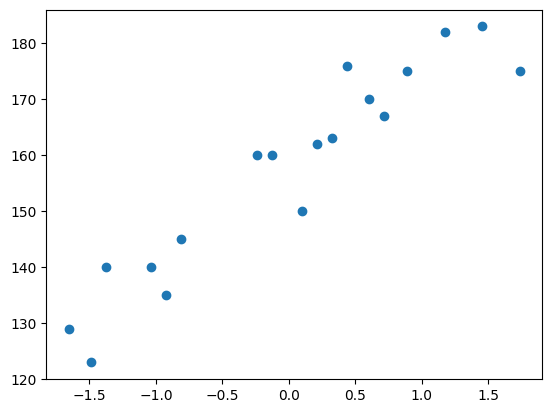

In [77]:
plt.scatter(X_train,y_train)
plt.show()

### StandardScaler
**StandardScaler is a preprocessing tool in machine learning (specifically in the scikit-learn library) used to resize your data so that it follows a standard normal distribution**.
When we use it, we are transforming your features so they have a mean of 0 and a standard deviation of 1.
    
**Why do we use it?**
Many machine learning algorithms are sensitive to the "scale" of your data. If one feature has values from 0 to 1 (like "age") and another has values from 0 to 1,000,000 (like "income"), the algorithm might mistakenly think the larger numbers are more important.StandardScaler levels the playing field so the model treats every feature equally.

**How it works**(The Math)
For every individual value in your dataset, the scaler performs the following calculation:
$$z = \frac{x - \mu}{\sigma}$$
Where:
- $x$: The original value.
- $\mu$: The mean of the feature.$
- \sigma$: The standard deviation of the feature.

**Key Rules for Using It**
To use StandardScaler correctly and avoid "Data Leakage" (letting the model peek at the test data), we must follow this specific order:
- Split your data into Training and Test sets first.
- fit() the scaler only on the Training data (this calculates the mean and standard deviation).
- transform() both the Training and Test data using those calculated values.

**When should you use it?**
Essential for: Algorithms that rely on distance or gradients, like K-Nearest Neighbors (KNN), Support Vector Machines (SVM), Principal Component Analysis (PCA), and Neural Networks.Less critical for: Tree-based models like Random Forest or XGBoost, which aren't sensitive to the scale of the data.

**Steps happening here:**

- fit() → calculates mean and standard deviation

- transform() → converts data using the formula

- fit_transform() → does both together

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
regressor = LinearRegression()

In [39]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
y_pred = regressor.predict(X_test)

In [81]:
print(regressor.coef_)
print(regressor.intercept_)

[[0.9630459]]
[85.96709053]


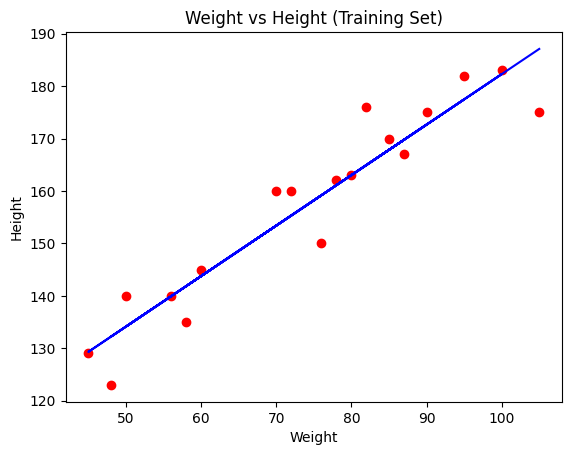

In [43]:
## visualizing training set results

plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Weight vs Height (Training Set)')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

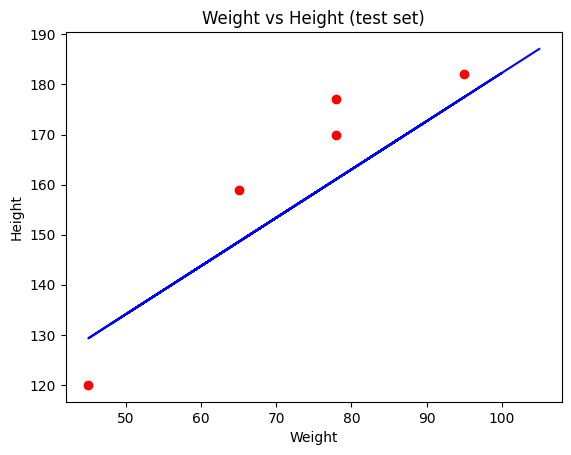

In [44]:
## Visualizing the test set results

plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Weight vs Height (test set)')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [45]:
## making a single prediction

print(regressor.predict([[3]]))

[[88.85622824]]


C:\Users\Chitrbatala\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Performance Metrics

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [83]:
# MAE -> Average absolute difference between actual & predicted salary.
# MSE -> Penalizes large errors more heavily.
# RMSE -> Error in same unit as salary (₹).
# R2 Score -> How much variance in salary is explained by experience
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 9.822657814519232
MSE: 109.77592599051658
RMSE: 10.477400726827078
R2 Score: 0.776986986042344
